# Example: Approximating $\pi$ using Markov Chain Monte Carlo (MCMC)

Sam Foreman [](https://orcid.org/0000-0002-9981-0876)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
Huihuo Zheng
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/huihuo-zheng>))  
2025-07-15

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/00-intro-AI-HPC/5-mcmc-example/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/docs/00-intro-AI-HPC/5-mcmc-example/README.md)

> **Parallel Computing**
>
> **Parallel computing** refers to the process of breaking down larger
> problems into smaller, independent, often similar parts that can be
> executed simultaneously by multiple processors communicating via
> network or shared memory, the results of which are combined upon
> completion as part of an overall algorithm.

## Example: Estimate $\pi$

We can calculate the value of $\pi$ using a MPI parallelized version of
the Monte Carlo method. The basic idea is to estimate $\pi$ by randomly
sampling points within a square and determining how many fall inside a
quarter circle inscribed within that square.

<figure>
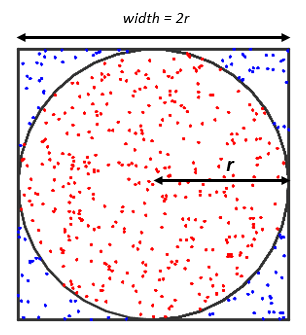
<figcaption aria-hidden="true"><span
class="math inline"><em>π</em></span></figcaption>
</figure>

The ratio between the area of the circle and the square is

$$\frac{N_\text{in}}{N_\text{total}} = \frac{\pi r^2}{4r^2} = \frac{\pi}{4}$$

Therefore, we can calculate $\pi$ using
$\pi = \frac{4N_\text{in}}{N_\text{total}}$

In [1]:
import numpy as np
import random
import time

import plotly.graph_objects as go
from bootcamp.plotly_theme import apply_theme, COLORS
apply_theme()   # house style: Iosevka font, transparent bg, #838383 text, material colors

from rich import print

# --- sample N random points in the square [-0.5, 0.5] x [-0.5, 0.5] ---
N = 2000
rng = np.random.default_rng(1234)
pts = rng.uniform(-0.5, 0.5, size=(N, 2))
inside = np.sqrt((pts ** 2).sum(axis=1)) < 0.5   # True if inside the circle
Nin = int(inside.sum())
pi_est = 4.0 * Nin / N
print(f"Pi ≈ {pi_est:.4f}   (N_in / N_total = {Nin}/{N})")

# --- interactive scatter with a fill-in slider: drag (or hit ▶) to watch the
#     points accumulate and the estimate of π converge as more samples land ---
theta = np.linspace(0, 2 * np.pi, 200)
circle = go.Scatter(x=0.5 * np.cos(theta), y=0.5 * np.sin(theta), mode="lines",
                    line=dict(color=COLORS["grey"], width=2), name="circle", hoverinfo="skip")

# running count of points-inside, so each step's π estimate is O(1)
cum_inside = np.cumsum(inside)
steps = list(range(100, N + 1, 100))   # reveal 100 points per frame

def frame_traces(n):
    ins, outs = inside[:n], ~inside[:n]
    return [
        circle,
        go.Scatter(x=pts[:n][ins, 0], y=pts[:n][ins, 1], mode="markers", name="inside",
                   marker=dict(size=4, color=COLORS["red"], opacity=0.7)),
        go.Scatter(x=pts[:n][outs, 0], y=pts[:n][outs, 1], mode="markers", name="outside",
                   marker=dict(size=4, color=COLORS["blue"], opacity=0.7)),
    ]

frames = [go.Frame(name=str(n), data=frame_traces(n),
                   layout=go.Layout(title=f"π ≈ {4*cum_inside[n-1]/n:.4f}   (4 × {cum_inside[n-1]}/{n})"))
          for n in steps]

fig = go.Figure(data=frame_traces(steps[0]), frames=frames)
fig.update_layout(
    title=f"π ≈ {4*cum_inside[steps[0]-1]/steps[0]:.4f}   (4 × {cum_inside[steps[0]-1]}/{steps[0]})",
    width=480, height=540, showlegend=True,
    xaxis=dict(range=[-0.5, 0.5], scaleanchor="y", constrain="domain"),
    yaxis=dict(range=[-0.5, 0.5]),
    updatemenus=[dict(type="buttons", showactive=False, x=0, y=-0.08, xanchor="left",
        buttons=[dict(label="▶ Play", method="animate",
                      args=[None, dict(frame=dict(duration=200, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, x=0.1, len=0.9, y=-0.02, currentvalue=dict(prefix="samples: "),
        steps=[dict(method="animate", label=str(n),
                    args=[[str(n)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for n in steps])],
)
fig.show()

Pi ≈ 3.1400 ( N_in / N_total = 1570 / 2000 )

### MPI example

| Nodes  | PyTorch-2.5 | PyTorch-2.7 | PyTorch-2.8 |
|:------:|:-----------:|:-----------:|:-----------:|
| N1xR12 |    17.39    |    31.01    |    33.09    |
| N2xR12 |    3.81     |    32.71    |    33.26    |

In [2]:
from mpi4py import MPI
import numpy as np
import random
import time
comm = MPI.COMM_WORLD

N = 5000000
Nin = 0
t0 = time.time()
for i in range(comm.rank, N, comm.size):
    x = random.uniform(-0.5, 0.5)
    y = random.uniform(-0.5, 0.5)
    if (np.sqrt(x*x + y*y) < 0.5):
        Nin += 1
res = np.array(Nin, dtype='d')
res_tot = np.array(Nin, dtype='d')
comm.Allreduce(res, res_tot, op=MPI.SUM)
t1 = time.time()
if comm.rank==0:
    print(res_tot/float(N/4.0))
    print("Time: %s" %(t1 - t0))

3.1418464

Time: 1.8707478046417236

### Running $\pi$ example on Google Colab

- Go to https://colab.research.google.com/, sign in or sign up
- “File”-\> “open notebook”
- Choose `01_intro_AI_on_Supercomputer/00_mpi.ipynb` from the list
  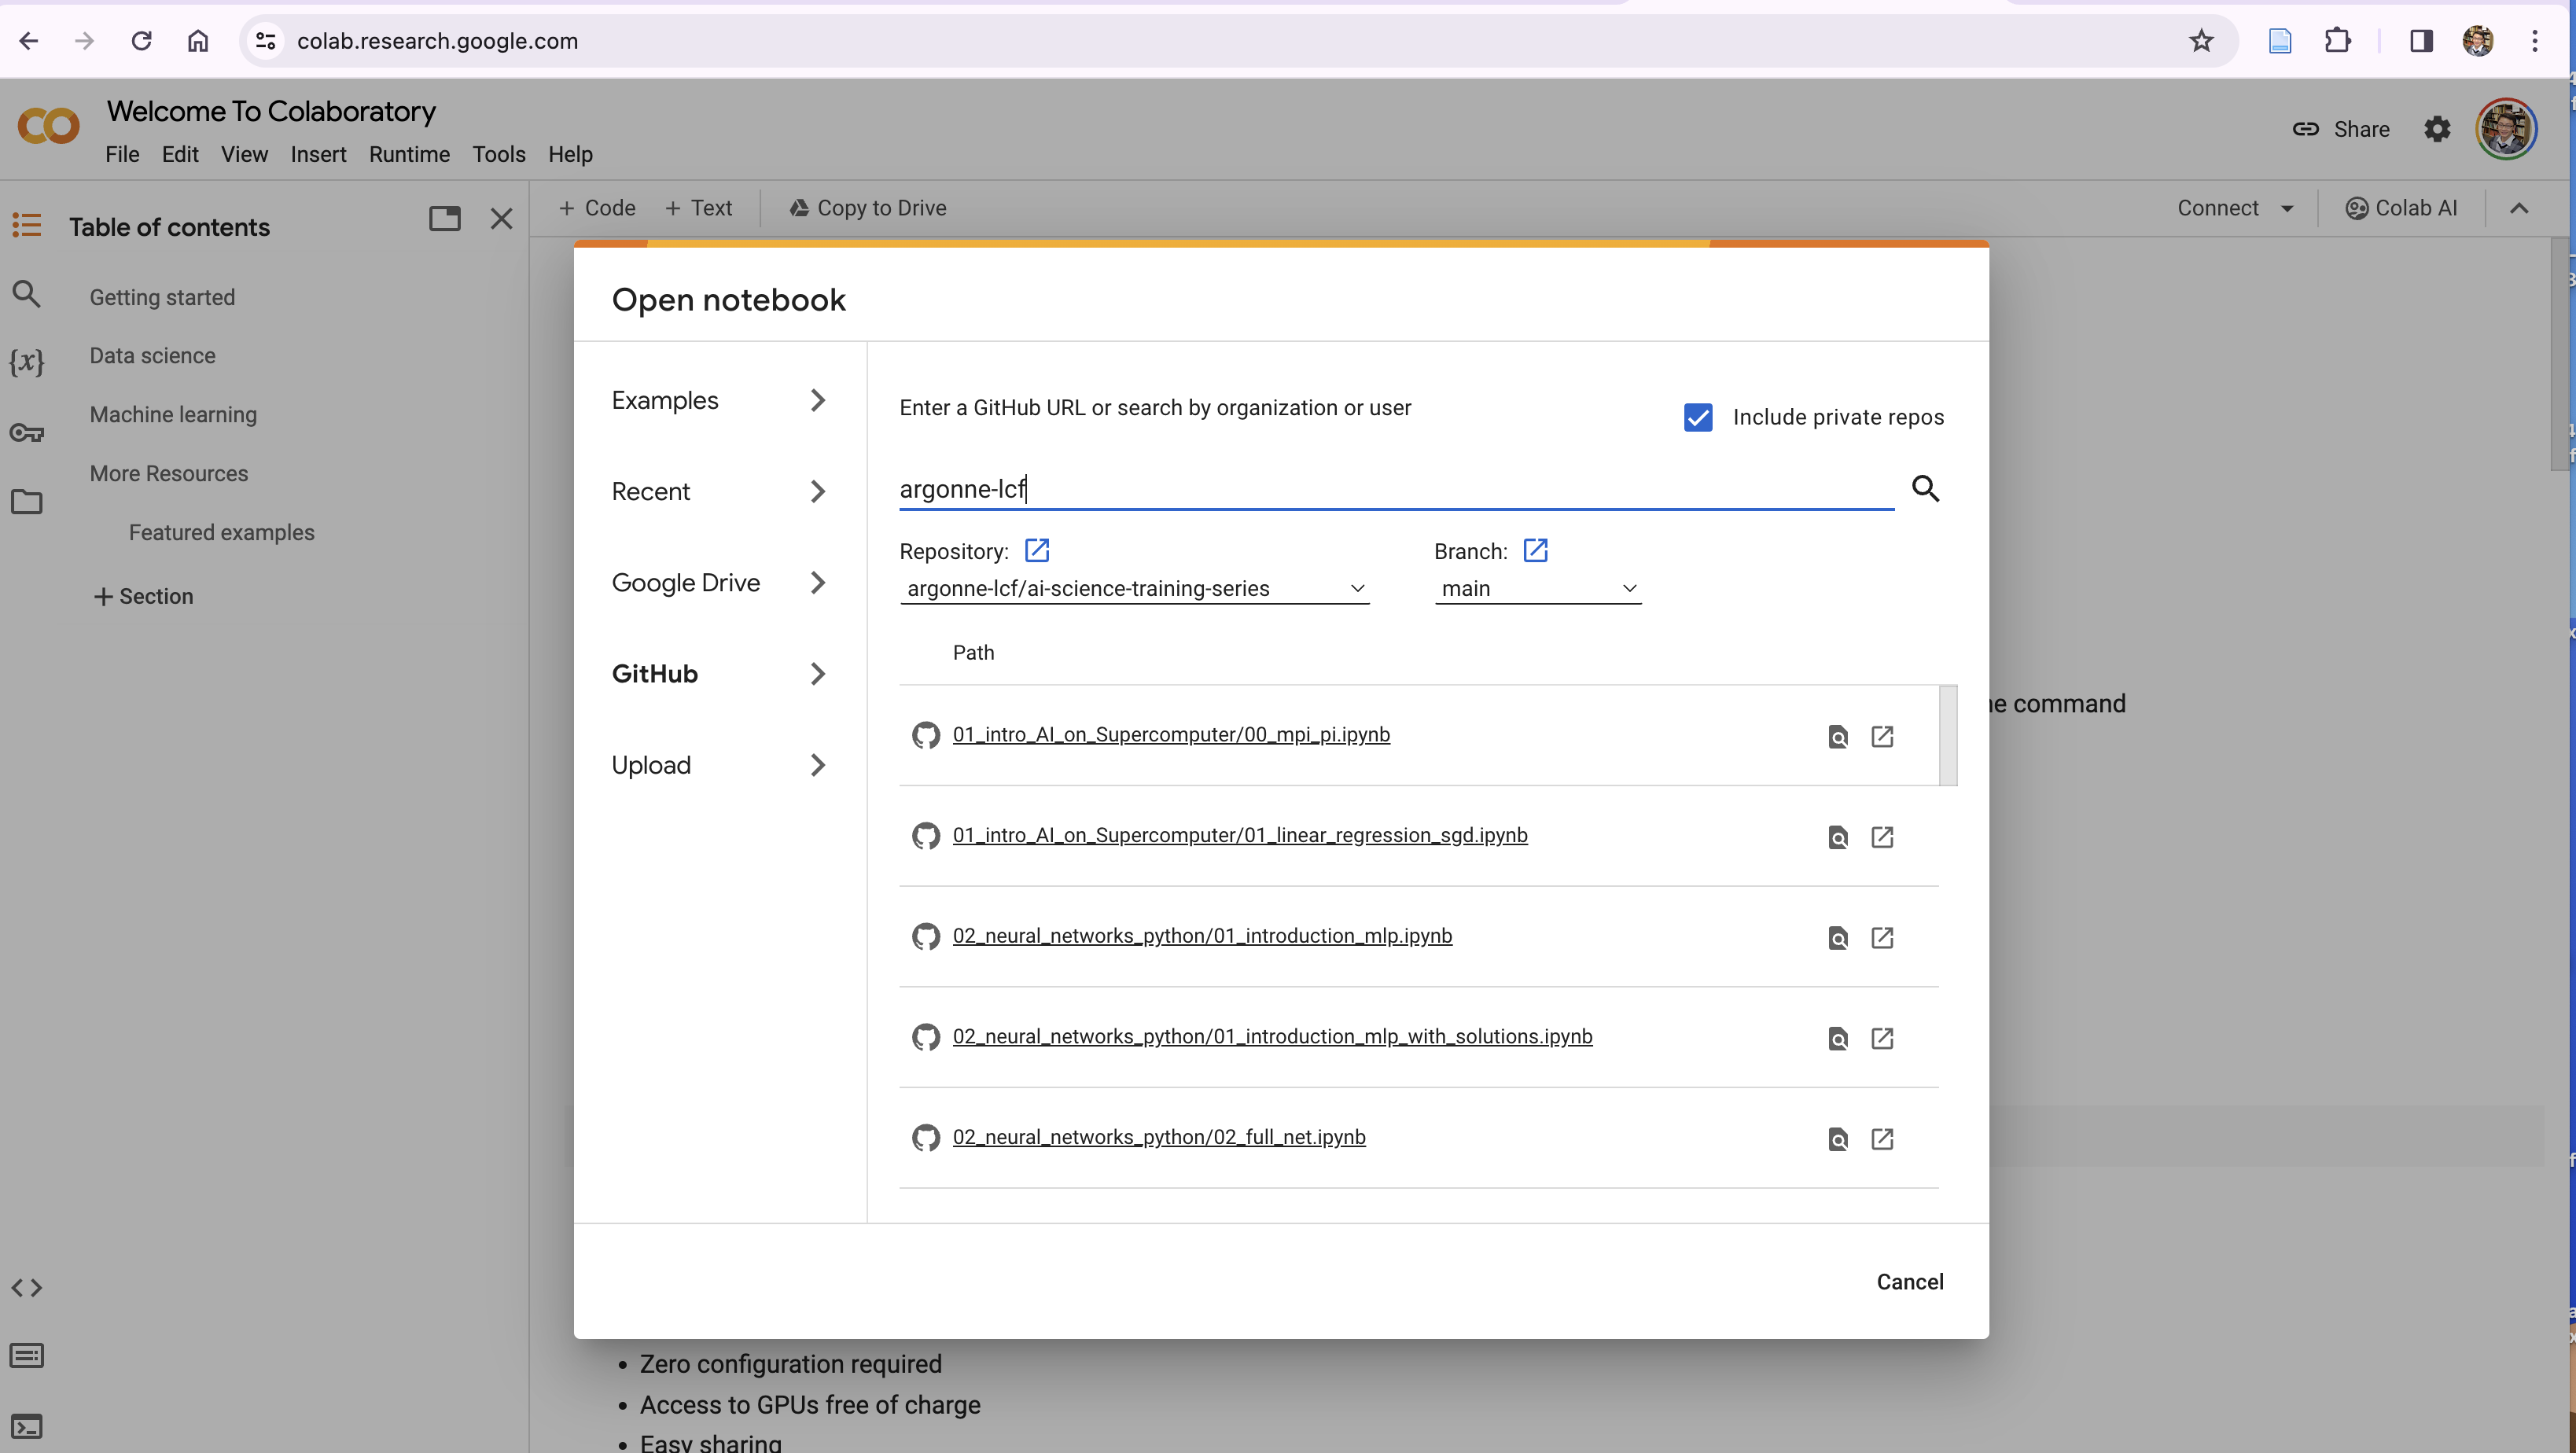

In [3]:
! wget https://raw.githubusercontent.com/argonne-lcf/ai-science-training-series/main/01_intro_AI_on_Supercomputer/mpi_pi.py
! pip install mpi4py

In [4]:
! mpirun -np 1 --allow-run-as-root python mpi_pi.py

Number of processes: 1
Pi = 3.1420592
Time: 1.639554

In [5]:
! mpirun -np 2 --allow-run-as-root --oversubscribe python mpi_pi.py

Number of processes: 2
Pi = 3.1412104
Time: 0.885421

In [6]:
! mpirun -np 4 --allow-run-as-root --oversubscribe python mpi_pi.py

Number of processes: 4
Pi = 3.1407688
Time: 0.484927

### Running $\pi$ on Polaris

``` bash
ssh <username>@polaris.alcf.anl.gov
qsub -A ALCFAITP -l select=1 -q ALCFAITP -l walltime=0:30:00 -l filesystems=home:eagle
# choose debug queue outside of the class
# qsub -A ALCFAITP -l select=1 -q debug -l walltime=0:30:00 -l filesystems=home:eagle

module load conda/2023-10-04
conda activate /soft/datascience/ALCFAITP/2023-10-04
git clone git@github.com:argonne-lcf/ai-science-training-series.git
cd ai-science-training-series/01_intro_AI_on_Supercomputer/
mpirun -np 1 python mpi_pi.py   # 3.141988,   8.029037714004517  s
mpirun -np 2 python mpi_pi.py   # 3.1415096   4.212774038314819  s
mpirun -np 4 python mpi_pi.py   # 3.1425632   2.093632459640503  s
mpirun -np 8 python mpi_pi.py   # 3.1411632   1.0610620975494385 s
```

## Where this goes next

The same idea of splitting work across many processes — which we just
used with MPI to estimate $\pi$ — is exactly what powers **distributed
training** of modern AI models (data parallelism, model parallelism, and
more).

> **➡️ Next steps**
>
> We cover distributed and parallel training in depth in [**\[01\]
> Distributed
> Training**](../../01-neural-networks/4-distributed-training/index.qmd)
> (DDP, FSDP, tensor/pipeline parallelism, collective communication) and
> apply it to LLMs in [**\[02\] Parallel
> Training**](../../02-llms/1-parallel-training/index.qmd).